# Feature Engineering

Builds the feature matrix for modeling. Feature logic lives in src/features.py so training and the API use the exact same code.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src')
from features import (
    add_calendar_features, add_lag_features, add_rolling_features,
    add_days_since_last_sale, add_price_ffill, add_sku_static_features,
    add_category_encoding, add_market_trend_features, FEATURE_COLUMNS,
)

df = pd.read_csv('../data/processed/demand_features.csv',
                  dtype={'stock_code': str, 'category_code': str},
                  parse_dates=['sale_date'])
df = df.sort_values(['stock_code', 'sale_date']).reset_index(drop=True)
print(f"{len(df):,} rows, {df['stock_code'].nunique():,} SKUs")

2,252,727 rows, 4,746 SKUs


## Calendar features

In [2]:
df = add_calendar_features(df)
df[['sale_date','day_of_week','is_weekend','is_uk_holiday','days_to_christmas']].head()

,sale_date,day_of_week,is_weekend,is_uk_holiday,days_to_christmas
0,2009-12-01,1,0,0,24
1,2009-12-02,2,0,0,23
2,2009-12-03,3,0,0,22
3,2009-12-04,4,0,0,21
4,2009-12-05,5,1,0,20


## Lags

In [3]:
df = add_lag_features(df)
sku = df['stock_code'].iloc[0]
df[df['stock_code']==sku][['sale_date','units_sold','lag_1d','lag_7d','lag_28d']].head(10)

,sale_date,units_sold,lag_1d,lag_7d,lag_28d
0,2009-12-01,12,NaN,NaN,NaN
1,2009-12-02,0,12.0,NaN,NaN
2,2009-12-03,6,0.0,NaN,NaN
3,2009-12-04,73,6.0,NaN,NaN
4,2009-12-05,0,73.0,NaN,NaN
5,2009-12-06,49,0.0,NaN,NaN
6,2009-12-07,2,49.0,NaN,NaN
7,2009-12-08,12,2.0,12.0,NaN
8,2009-12-09,0,12.0,0.0,NaN
9,2009-12-10,1,0.0,6.0,NaN


## Rolling features

shift(1) before rolling so the window never sees the current row.

In [4]:
df = add_rolling_features(df)
df[df['stock_code']==sku][['sale_date','units_sold','rolling_7d_mean','rolling_28d_mean']].head(10)

,sale_date,units_sold,rolling_7d_mean,rolling_28d_mean
0,2009-12-01,12,NaN,NaN
1,2009-12-02,0,NaN,NaN
2,2009-12-03,6,NaN,NaN
3,2009-12-04,73,6.000000,NaN
4,2009-12-05,0,22.750000,NaN
5,2009-12-06,49,18.200000,NaN
6,2009-12-07,2,23.333333,NaN
7,2009-12-08,12,20.285714,NaN
8,2009-12-09,0,20.285714,NaN
9,2009-12-10,1,20.285714,NaN


In [ ]:
# quick sanity check 
sku_df = df[df['stock_code']==sku].reset_index(drop=True)
row = 10
manual = sku_df['units_sold'].iloc[row-7:row].mean()
pipeline = sku_df['rolling_7d_mean'].iloc[row]
assert abs(manual - pipeline) < 1e-9
print('ok, matches:', manual, pipeline)

ok, matches: 19.571428571428573 19.571428571428573


## Category trend

Per-SKU rolling means lag too much to catch a demand ramp early - this adds a faster category-level signal.

In [6]:
df = add_market_trend_features(df)
df[['sale_date','category_code','units_sold','category_trend_7d','category_trend_28d']].head()

,sale_date,category_code,units_sold,category_trend_7d,category_trend_28d
0,2009-12-01,10,12,NaN,NaN
1,2009-12-02,10,0,NaN,NaN
2,2009-12-03,10,6,NaN,NaN
3,2009-12-04,10,73,115.00,NaN
4,2009-12-05,10,0,136.25,NaN


## Days since last sale, price forward-fill

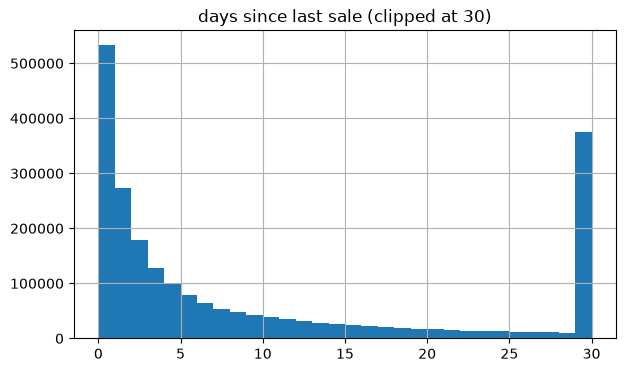

In [7]:
df = add_days_since_last_sale(df)
df = add_price_ffill(df)

df['days_since_last_sale'].clip(upper=30).hist(bins=30, figsize=(7,4))
plt.title('days since last sale (clipped at 30)')
plt.show()

## Train-only encodings

Fit only on train rows so nothing from the test period leaks backward.

In [8]:
cutoff = df['sale_date'].quantile(0.85)
train_mask = df['sale_date'] < cutoff
print('cutoff:', cutoff.date())

df = add_sku_static_features(df, train_mask)
df = add_category_encoding(df, train_mask)

cutoff: 2011-08-12


## Drop warm-up rows, save

## Weekly aggregation branch

Note: only carries `units_sold`-derived lag/rolling features forward — `avg_unit_price`, `category_code`, and calendar features are not re-added here.

In [9]:
df_weekly = (df.groupby(['stock_code', pd.Grouper(key='sale_date', freq='W')])['units_sold']
               .sum()
               .reset_index())

df_weekly = add_lag_features(df_weekly)
df_weekly = add_rolling_features(df_weekly)

df_weekly.to_csv('../data/processed/model_ready_weekly.csv', index=False)
print(f"saved model_ready_weekly.csv, {len(df_weekly):,} rows")

saved model_ready_weekly.csv, 323,895 rows


In [10]:
before = len(df)
df_model = df.dropna(subset=['lag_1d','lag_7d','lag_28d','rolling_28d_mean','avg_unit_price','category_trend_28d']).copy()
print(f"dropped {before - len(df_model):,} warm-up rows, {len(df_model):,} left")

assert df_model[FEATURE_COLUMNS].isna().sum().sum() == 0

df_model.to_csv('../data/processed/model_ready.csv', index=False)
print('saved model_ready.csv')

dropped 128,117 warm-up rows, 2,124,610 left
saved model_ready.csv
